In [ ]:
# Clonar o repositório
!git clone https://github.com/Raquerd/FIAP_Project_CardioIA.git

Cloning into 'FIAP_Project_CardioIA'...
remote: Enumerating objects: 853, done.
remote: Counting objects: 100% (853/853), done.
remote: Compressing objects: 100% (825/825), done.
remote: Total 853 (delta 29), reused 846 (delta 23), pack-reused 0 (from 0)
Receiving objects: 100% (853/853), 12.39 MiB | 25.74 MiB/s, done.
Resolving deltas: 100% (29/29), done.


In [ ]:
# Bibliotecas utilizadas no projeto

import os
import numpy as np
import matplotlib.pyplot as plt


from PIL import Image

In [ ]:
# Verificando se as pastas do dataset foram encontradas

for raiz, pastas, arquivos in os.walk("FIAP_Project_CardioIA"):
    if "M" in pastas or "N" in pastas:
        print(raiz)

FIAP_Project_CardioIA/assets/ECG_image_data/train
FIAP_Project_CardioIA/assets/ECG_image_data/test


# 1. Análise Inicial do Dataset

Nesta etapa foi realizada a contagem das imagens disponíveis em cada classe do dataset.

As imagens estão organizadas em duas categorias:

- N (Normal): batimentos cardíacos normais.
- M (Anormal): batimentos cardíacos anormais.

O objetivo desta análise inicial é verificar a distribuição das classes e identificar possíveis desequilíbrios que possam impactar o treinamento do modelo.

In [ ]:
# Contagem das imagens por classe

train_m = len(os.listdir("FIAP_Project_CardioIA/assets/ECG_image_data/train/M"))
train_n = len(os.listdir("FIAP_Project_CardioIA/assets/ECG_image_data/train/N"))

test_m = len(os.listdir("FIAP_Project_CardioIA/assets/ECG_image_data/test/M"))
test_n = len(os.listdir("FIAP_Project_CardioIA/assets/ECG_image_data/test/N"))

print(f"Treino - Anormais (M): {train_m}")
print(f"Treino - Normais (N): {train_n}")
print()

print(f"Teste - Anormais (M): {test_m}")
print(f"Teste - Normais (N): {test_n}")

Treino - Anormais (M): 200
Treino - Normais (N): 162

Teste - Anormais (M): 201
Teste - Normais (N): 200


# 2. Visualização das Imagens

Antes de aplicar qualquer técnica de pré-processamento, é importante visualizar algumas amostras do dataset.

Essa etapa permite verificar a qualidade das imagens e compreender visualmente as diferenças entre as classes normal (N) e anormal (M).

In [ ]:
# Importando bibliotecas para visualização

from PIL import Image
import matplotlib.pyplot as plt

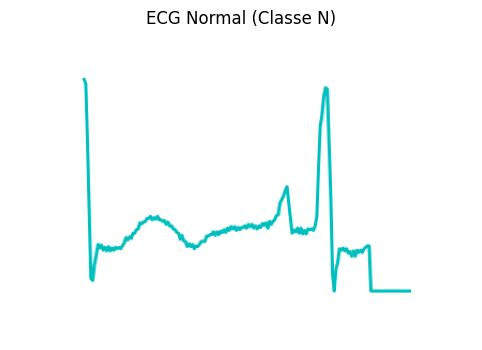

In [ ]:
# Exemplo de ECG normal

caminho_normal = "FIAP_Project_CardioIA/assets/ECG_image_data/train/N"

arquivo_normal = os.listdir(caminho_normal)[0]

img_normal = Image.open(
    os.path.join(caminho_normal, arquivo_normal)
)

plt.figure(figsize=(10,4))
plt.imshow(img_normal)
plt.title("ECG Normal (Classe N)")
plt.axis("off")
plt.show()

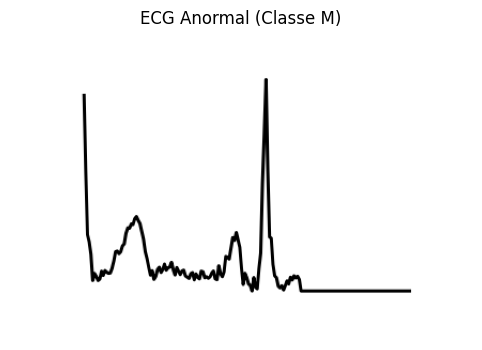

In [ ]:
# Exemplo de ECG anormal

caminho_anormal = "FIAP_Project_CardioIA/assets/ECG_image_data/train/M"

arquivo_anormal = os.listdir(caminho_anormal)[0]

img_anormal = Image.open(
    os.path.join(caminho_anormal, arquivo_anormal)
)

plt.figure(figsize=(10,4))
plt.imshow(img_anormal)
plt.title("ECG Anormal (Classe M)")
plt.axis("off")
plt.show()

# 3. Verificação da Consistência Visual

Durante a inspeção inicial do dataset foi observado que algumas imagens apresentam diferenças de coloração entre as classes.

Essa análise é importante porque modelos de Deep Learning podem aprender características visuais irrelevantes para a classificação, como cores ou estilos de renderização, em vez dos padrões médicos presentes no traçado do eletrocardiograma.

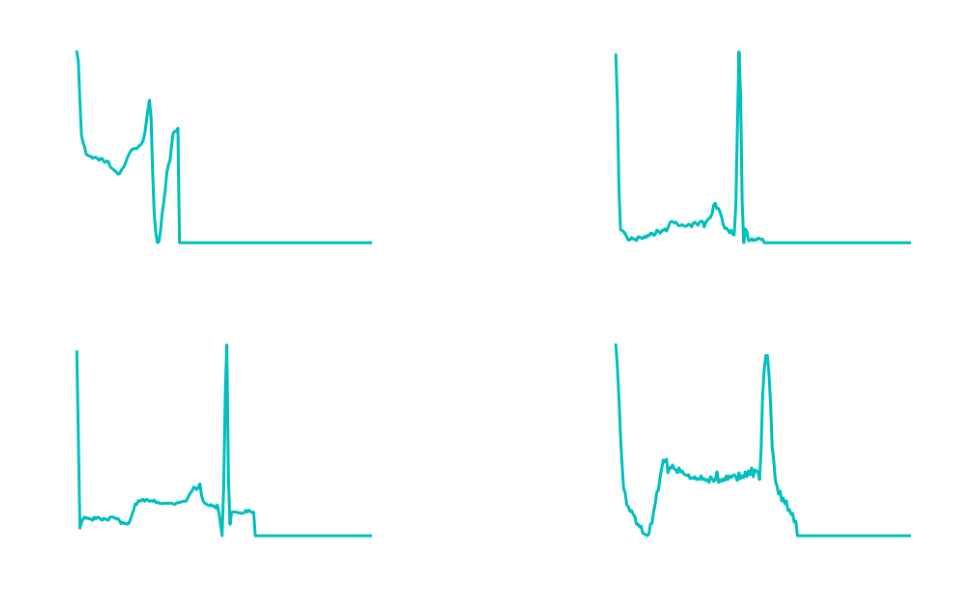

In [ ]:
# Visualizando múltiplas imagens da classe Normal (N)

import random

caminho_normal = "FIAP_Project_CardioIA/assets/ECG_image_data/train/N"

arquivos = random.sample(os.listdir(caminho_normal), 4)

plt.figure(figsize=(12,6))

for i, arquivo in enumerate(arquivos):
    img = Image.open(os.path.join(caminho_normal, arquivo))

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

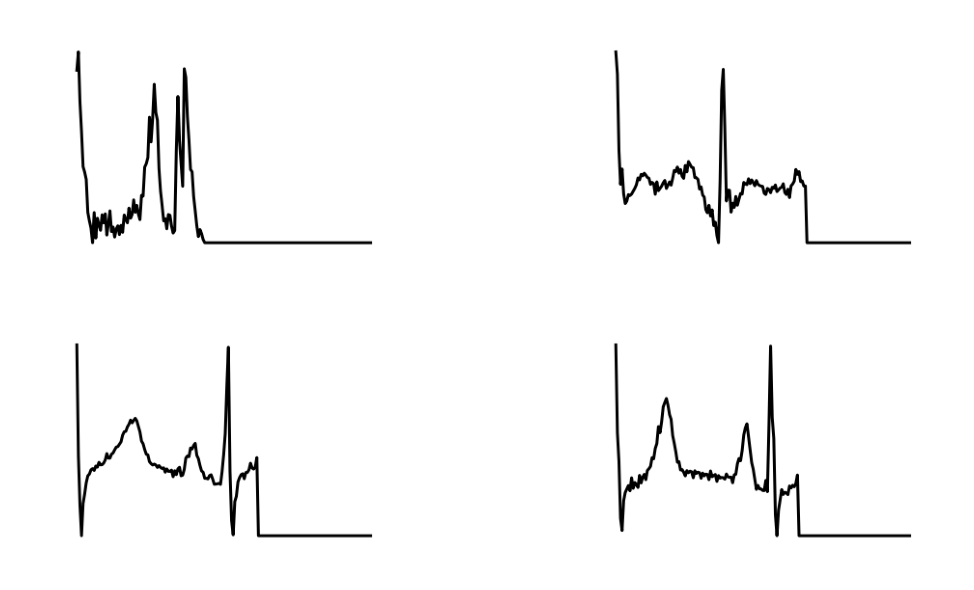

In [ ]:
# Visualizando múltiplas imagens da classe Anormal (M)

caminho_anormal = "FIAP_Project_CardioIA/assets/ECG_image_data/train/M"

arquivos = random.sample(os.listdir(caminho_anormal), 4)

plt.figure(figsize=(12,6))

for i, arquivo in enumerate(arquivos):
    img = Image.open(os.path.join(caminho_anormal, arquivo))

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

# 4. Inspeção das Dimensões das Imagens

Antes do redimensionamento, foi realizada uma análise das dimensões originais das imagens do dataset para verificar possíveis diferenças de resolução entre as amostras.

In [ ]:
# Verificando as dimensões de uma imagem normal e uma anormal

from PIL import Image
import os

img_normal = Image.open(
    os.path.join(
        "FIAP_Project_CardioIA/assets/ECG_image_data/train/N",
        os.listdir("FIAP_Project_CardioIA/assets/ECG_image_data/train/N")[0]
    )
)

img_anormal = Image.open(
    os.path.join(
        "FIAP_Project_CardioIA/assets/ECG_image_data/train/M",
        os.listdir("FIAP_Project_CardioIA/assets/ECG_image_data/train/M")[0]
    )
)

print("Dimensão imagem normal:", img_normal.size)
print("Dimensão imagem anormal:", img_anormal.size)
print("Modo imagem normal:", img_normal.mode)
print("Modo imagem anormal:", img_anormal.mode)

Dimensão imagem normal: (432, 288)
Dimensão imagem anormal: (432, 288)
Modo imagem normal: RGBA
Modo imagem anormal: RGBA


# 5. Análise das Características das Imagens

A inspeção inicial mostrou que todas as imagens possuem resolução de 432 × 288 pixels e formato RGBA.

Também foi observado que as imagens das classes Normal (N) e Anormal (M) apresentam diferenças de coloração, o que pode influenciar o treinamento do modelo caso não seja tratado adequadamente.

Para garantir a padronização dos dados de entrada, será realizado o pré-processamento das imagens.

# 6. Pré-processamento das Imagens

Nesta etapa serão aplicadas as seguintes transformações:

- Conversão do formato RGBA para RGB.
- Redimensionamento para 224 × 224 pixels.
- Normalização dos valores dos pixels para o intervalo [0,1].

Essas técnicas ajudam a melhorar a estabilidade do treinamento e garantem compatibilidade com arquiteturas modernas de Deep Learning.

In [ ]:
# Bibliotecas para pré-processamento

import numpy as np
from PIL import Image

# Exemplo de pré-processamento de uma imagem

caminho = os.path.join(
    "FIAP_Project_CardioIA/assets/ECG_image_data/train/N",
    os.listdir("FIAP_Project_CardioIA/assets/ECG_image_data/train/N")[0]
)

img = Image.open(caminho)

# Converter RGBA para RGB
img = img.convert("RGB")

# Redimensionar
img = img.resize((224, 224))

# Converter para array NumPy
img_array = np.array(img)

# Normalizar para [0,1]
img_array = img_array / 255.0

print("Shape:", img_array.shape)
print("Valor mínimo:", img_array.min())
print("Valor máximo:", img_array.max())

Shape: (224, 224, 3)
Valor mínimo: 0.0
Valor máximo: 1.0


# 7. Divisão dos Dados

Para garantir uma avaliação confiável do modelo, foi utilizada uma divisão estratificada do dataset completo.

A estratégia adotada foi:

- 70% para treinamento
- 15% para validação
- 15% para teste

A divisão estratificada foi escolhida para preservar a proporção entre as classes Normal (N) e Anormal (M) em todos os conjuntos, reduzindo possíveis vieses durante o treinamento e a avaliação do modelo.

In [ ]:
# Bibliotecas para divisão dos dados

import os
import pandas as pd
from sklearn.model_selection import train_test_split

# Criando uma lista com todas as imagens do dataset

dados = []

pastas = [
    ("FIAP_Project_CardioIA/assets/ECG_image_data/train/N", "N"),
    ("FIAP_Project_CardioIA/assets/ECG_image_data/train/M", "M"),
    ("FIAP_Project_CardioIA/assets/ECG_image_data/test/N", "N"),
    ("FIAP_Project_CardioIA/assets/ECG_image_data/test/M", "M")
]

for pasta, classe in pastas:
    for arquivo in os.listdir(pasta):
        dados.append([
            os.path.join(pasta, arquivo),
            classe
        ])

df = pd.DataFrame(dados, columns=["caminho", "classe"])

print("Total de imagens:", len(df))
df.head()

# Primeira divisão: 70% treino e 30% restante

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["classe"],
    random_state=42
)

# Segunda divisão: 15% validação e 15% teste

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["classe"],
    random_state=42
)

# Verificando os resultados

print("Treino:", len(train_df))
print("Validação:", len(val_df))
print("Teste:", len(test_df))

Total de imagens: 763
Treino: 534
Validação: 114
Teste: 115


In [ ]:
# Exibindo a distribuição final dos dados

print(f"Treino: {len(train_df)} imagens")
print(f"Validação: {len(val_df)} imagens")
print(f"Teste: {len(test_df)} imagens")
print(f"Total: {len(df)} imagens")

Treino: 534 imagens
Validação: 114 imagens
Teste: 115 imagens
Total: 763 imagens


# 8. Resultados da Divisão

Após a aplicação do método de amostragem estratificada, o dataset foi dividido da seguinte forma:

| Conjunto | Quantidade de imagens |
|-----------|---------------------|
| Treino | 534 |
| Validação | 114 |
| Teste | 115 |

Essa distribuição fornece uma quantidade adequada de dados para aprendizado, monitoramento do desempenho durante o treinamento e avaliação final do modelo.

# 9. Organização Física dos Conjuntos

Após a divisão estratificada do dataset, as imagens foram organizadas em diretórios separados para treinamento, validação e teste.

Essa estrutura facilita a utilização de bibliotecas de Deep Learning, como TensorFlow e Keras, que realizam o carregamento automático das imagens a partir da organização em pastas.

In [ ]:
# Bibliotecas para manipulação dos arquivos

import os
import shutil

In [ ]:
# Criando a estrutura de pastas

base_dir = "dataset_final"

for conjunto in ["train", "validation", "test"]:
    for classe in ["M", "N"]:
        os.makedirs(
            os.path.join(base_dir, conjunto, classe),
            exist_ok=True
        )

print("Estrutura criada com sucesso!")

Estrutura criada com sucesso!


In [ ]:
# Função para copiar imagens para as novas pastas

def copiar_imagens(df, conjunto):

    for _, linha in df.iterrows():

        origem = linha["caminho"]
        classe = linha["classe"]

        destino = os.path.join(
            base_dir,
            conjunto,
            classe,
            os.path.basename(origem)
        )

        shutil.copy2(origem, destino)

In [ ]:
# Copiando as imagens

copiar_imagens(train_df, "train")
copiar_imagens(val_df, "validation")
copiar_imagens(test_df, "test")

print("Imagens copiadas com sucesso!")

Imagens copiadas com sucesso!


In [ ]:
# Conferindo o resultado final

for conjunto in ["train", "validation", "test"]:

    qtd_m = len(os.listdir(os.path.join(base_dir, conjunto, "M")))
    qtd_n = len(os.listdir(os.path.join(base_dir, conjunto, "N")))

    print(f"\n{conjunto.upper()}")
    print(f"M: {qtd_m}")
    print(f"N: {qtd_n}")
    print(f"Total: {qtd_m + qtd_n}")


TRAIN
M: 281
N: 253
Total: 534

VALIDATION
M: 60
N: 54
Total: 114

TEST
M: 60
N: 55
Total: 115


# 10. Conclusão

Foi realizado o processo completo de preparação dos dados para o projeto CardioIA, incluindo análise exploratória, inspeção das características das imagens, padronização, normalização e divisão estratificada dos conjuntos de dados.

As imagens foram organizadas em diretórios específicos para treinamento, validação e teste, permitindo sua utilização direta em modelos de Deep Learning.

Essas etapas garantem maior qualidade dos dados de entrada e contribuem para uma avaliação mais confiável da capacidade de generalização dos modelos de classificação de eletrocardiogramas.